[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdsanch1/simrc/blob/master/01.%20Parte%201/05.%20Clase%205/05Class%20NB.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/jdsanch1/SimRC/master?labpath=01.%20Parte%201%2F05.%20Clase%205%2F05Class%20NB.ipynb)

In [ ]:
import importlib, subprocess, sys

_required = ["yfinance", "pandas", "numpy", "matplotlib", "seaborn", "scipy", "sklearn", "statsmodels", "cvxpy"]
_missing  = [pkg for pkg in _required if importlib.util.find_spec(pkg) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)

# Clase 5:	Portafolios y riesgo - Selección

[Juan Diego Sánchez Torres](https://www.researchgate.net/profile/Juan_Diego_Sanchez_Torres), 

*Profesor*, [MAF ITESO](http://maf.iteso.mx/web/general/detalle?group_id=5858156)

+ Departamento de Matemáticas y Física
+ dsanchez@iteso.mx
+ Tel. 3669-34-34 Ext. 3069
+ Oficina: Cubículo 4, Edificio J, 2do piso

# 1. Motivación

En primer lugar, para poder bajar precios y información sobre opciones de Yahoo, es necesario cargar algunos paquetes de Python. En este caso, el paquete principal será Pandas. También, se usarán el Scipy y el Numpy para las matemáticas necesarias y, el Matplotlib y el Seaborn para hacer gráficos de las series de datos.

In [ ]:
#importar los paquetes que se van a usar
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.cluster import KMeans
import datetime
from datetime import datetime
import scipy.stats as stats
import scipy as sp
import cvxpy as cp
import scipy.cluster.hierarchy as hac
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#algunas opciones para Python
pd.set_option('display.notebook_repr_html', True)
pd.set_option('display.max_columns', 6)
pd.set_option('display.max_rows', 10)
pd.set_option('display.width', 78)
pd.set_option('precision', 3)

# 1. Uso de Pandas para descargar datos de precios de cierre

Ahora, en forma de función

In [2]:
def get_historical_closes(tickers, start_date, end_date):
    """Descarga precios de cierre ajustados usando yfinance."""
    import yfinance as yf
    import pandas as pd
    data = yf.download(tickers, start=start_date, end=end_date,
                       auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        closes = data["Close"]
    else:
        closes = data[["Close"]]
        closes.columns = [tickers] if isinstance(tickers, str) else list(tickers)
    closes.index.name = "Date"
    return closes.dropna()

Una vez cargados los paquetes, es necesario definir los tickers de las acciones que se usarán, la fuente de descarga (Yahoo en este caso, pero también se puede desde Google) y las fechas de interés. Con esto, la función *DataReader* del paquete *pandas_datareader* bajará los precios solicitados.

**Nota**: Usualmente, las distribuciones de Python no cuentan, por defecto, con el paquete *pandas_datareader*. Por lo que será necesario instalarlo aparte. El siguiente comando instala el paquete en Anaconda:
*conda install -c conda-forge pandas-datareader *

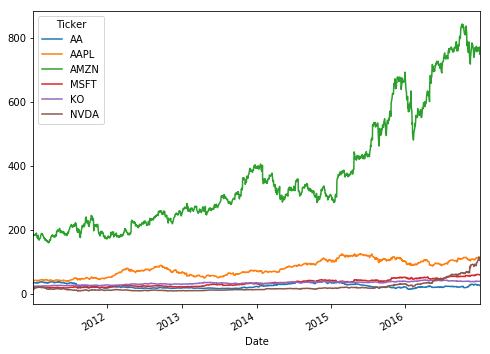

In [5]:
data=get_historical_closes(['AA','AAPL','AMZN','MSFT','KO','NVDA', '^GSPC'], '2025-01-01', '2025-03-27')
closes=data[['AA','AAPL','AMZN','MSFT','KO','NVDA']]
sp=data[['^GSPC']]
closes.plot(figsize=(8,6));

**Nota**: Para descargar datos de la bolsa mexicana de valores (BMV), el ticker debe tener la extensión MX. 
Por ejemplo: *MEXCHEM.MX*, *LABB.MX*, *GFINBURO.MX* y *GFNORTEO.MX*.

# 2. Formulación del riesgo de un portafolio

In [6]:
def calc_daily_returns(closes):
    return np.log(closes/closes.shift(1))[1:]

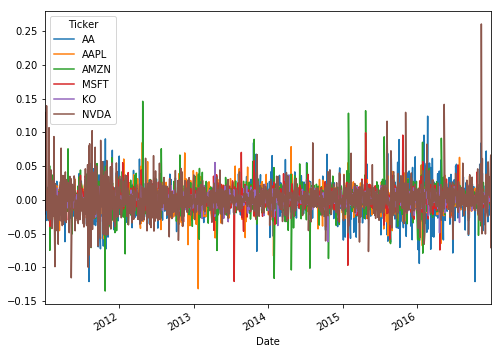

In [7]:
daily_returns=calc_daily_returns(closes)
daily_returns.plot(figsize=(8,6));

In [8]:
daily_returns.corr()

Ticker,AA,AAPL,AMZN,MSFT,KO,NVDA
Ticker,,,,,,
AA,1.000,0.315,0.299,0.378,0.330,0.370
AAPL,0.315,1.000,0.294,0.367,0.271,0.324
AMZN,0.299,0.294,1.000,0.390,0.288,0.300
MSFT,0.378,0.367,0.390,1.000,0.397,0.419
KO,0.330,0.271,0.288,0.397,1.000,0.277
NVDA,0.370,0.324,0.300,0.419,0.277,1.000


In [9]:
def calc_annual_returns(daily_returns):
    grouped = np.exp(daily_returns.groupby(lambda date: date.year).sum())-1
    return grouped

In [10]:
annual_returns = calc_annual_returns(daily_returns)
annual_returns

Ticker,AA,AAPL,AMZN,MSFT,KO,NVDA
2011,-0.448,0.229,-0.060,-0.048,0.104,-0.124
2012,0.017,0.326,0.449,0.058,0.065,-0.110
2013,0.241,0.081,0.590,0.443,0.172,0.335
2014,0.498,0.406,-0.222,0.276,0.053,0.274
2015,-0.368,-0.030,1.178,0.227,0.051,0.671
2016,0.201,0.125,0.109,0.151,-0.004,2.270


In [11]:
def calc_portfolio_var(returns, weights=None):
    if (weights is None):
        weights = np.ones(returns.columns.size)/returns.columns.size
    sigma = np.cov(returns.T,ddof=0)
    var = (weights * sigma * weights.T).sum()
    return var

In [12]:
calc_portfolio_var(annual_returns)

0.027039371744730999

In [13]:
def sharpe_ratio(returns, weights = None, risk_free_rate = 0.015):
    n = returns.columns.size
    if weights is None: weights = np.ones(n)/n
    var = calc_portfolio_var(returns, weights)
    means = returns.mean()
    return (means.dot(weights) - risk_free_rate)/np.sqrt(var)

In [14]:
sharpe_ratio(annual_returns)

1.2916170437110432

# 3. Selección de activos

In [15]:
daily_returns_mean=daily_returns.mean()
daily_returns_mean

Ticker
AA     -1.547e-04
AAPL    6.584e-04
AMZN    9.303e-04
MSFT    6.380e-04
KO      2.776e-04
NVDA    1.313e-03
dtype: float64

In [16]:
daily_returns_std=daily_returns.std()
daily_returns_std

Ticker
AA      0.023
AAPL    0.016
AMZN    0.020
MSFT    0.015
KO      0.009
NVDA    0.024
dtype: float64

In [17]:
daily_returns_ms=pd.concat([daily_returns_mean, daily_returns_std], axis=1)
daily_returns_ms

,0,1
Ticker,,
AA,-1.547e-04,0.023
AAPL,6.584e-04,0.016
AMZN,9.303e-04,0.020
MSFT,6.380e-04,0.015
KO,2.776e-04,0.009
NVDA,1.313e-03,0.024


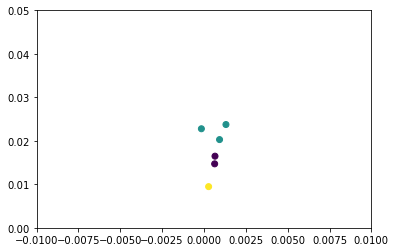

In [18]:
random_state = 10
y_pred = KMeans(n_clusters=3, random_state=random_state).fit_predict(daily_returns_ms)
plt.scatter(daily_returns_mean, daily_returns_std, c=y_pred);
plt.axis([-0.01, 0.01, 0, 0.05]);

In [19]:
corr_mat=daily_returns.corr(method='spearman')
corr_mat

Ticker,AA,AAPL,AMZN,MSFT,KO,NVDA
Ticker,,,,,,
AA,1.000,0.329,0.344,0.395,0.333,0.400
AAPL,0.329,1.000,0.343,0.386,0.270,0.349
AMZN,0.344,0.343,1.000,0.444,0.351,0.379
MSFT,0.395,0.386,0.444,1.000,0.420,0.444
KO,0.333,0.270,0.351,0.420,1.000,0.286
NVDA,0.400,0.349,0.379,0.444,0.286,1.000


In [20]:
Z = hac.linkage(corr_mat, 'single')

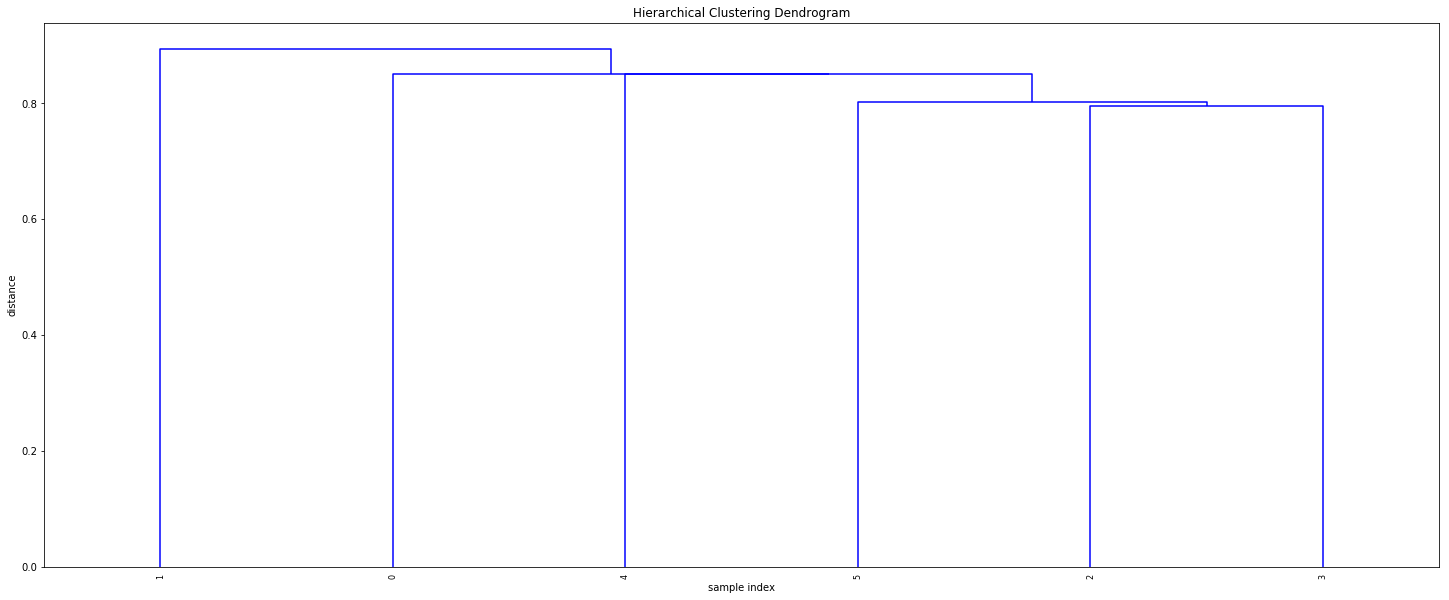

In [21]:
# Plot the dendogram
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
hac.dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)
plt.show()

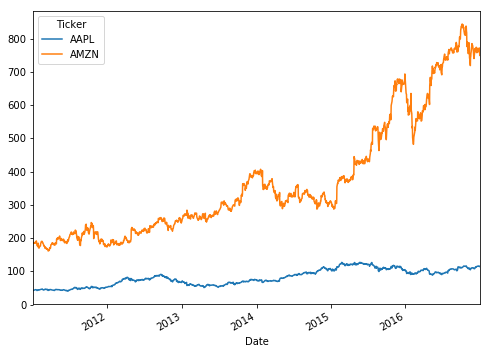

In [22]:
selected=closes[['AAPL', 'AMZN']]
selected.plot(figsize=(8,6));

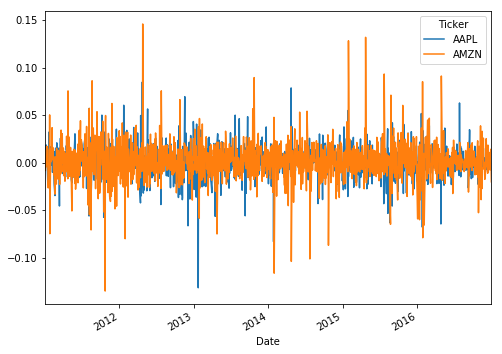

In [23]:
daily_returns_sel=calc_daily_returns(selected)
daily_returns_sel.plot(figsize=(8,6));

In [41]:
annual_returns_sel = calc_annual_returns(daily_returns_sel)
annual_returns_sel

Ticker,AAPL,AMZN
2011,0.229,-0.060
2012,0.326,0.449
2013,0.081,0.590
2014,0.406,-0.222
2015,-0.030,1.178
2016,0.125,0.109


# 4. Optimización de portafolios con CVXPY (DCP)

Utilizamos **CVXPY** con el enfoque de **Programación Convexa Disciplinada** para encontrar el portafolio óptimo y trazar la frontera eficiente.

In [ ]:
def optimal_portfolio(profits, r, allow_short=True):
    """Maximizar el ratio de Sharpe usando CVXPY (DCP).

    Transformación: min y'Σy  s.t. (μ-r)'y = 1, sum(y) = κ, y ≥ 0
    Luego w* = y*/κ*.
    """
    n = len(profits.T)
    mean_vector = np.mean(profits).values
    cov_matrix = np.cov(profits.T)
    excess = mean_vector - r

    y = cp.Variable(n)
    kappa = cp.Variable(nonneg=True)
    objective = cp.Minimize(cp.quad_form(y, cov_matrix))
    constraints = [excess @ y == 1, cp.sum(y) == kappa]
    if not allow_short:
        constraints.append(y >= 0)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)

    w_opt = y.value / kappa.value
    return type('Result', (), {'x': w_opt, 'fun': prob.value, 'success': prob.status == 'optimal'})()

In [35]:
opt=optimal_portfolio(annual_returns_sel, 0.015)
opt

array([ 0.77112041,  0.22887959])

In [48]:
annual_returns_sel.dot(opt.x)

2011    0.163
2012    0.354
2013    0.197
2014    0.262
2015    0.246
2016    0.121
dtype: float64

In [51]:
asp=calc_annual_returns(calc_daily_returns(sp))
asp

Ticker,^GSPC
2011,-0.011
2012,0.134
2013,0.296
2014,0.114
2015,-0.007
2016,0.095


In [ ]:
def calc_efficient_frontier(returns, n_points=150):
    """Frontera eficiente mediante QP paramétrico con CVXPY (DCP).

    Para cada rendimiento objetivo r*:
        minimizar   w' Σ w
        sujeto a    μ' w = r*,  Σ wᵢ = 1,  wᵢ ≥ 0
    """
    n = returns.columns.size
    mu = returns.mean().values
    Sigma = np.cov(returns.T)

    w = cp.Variable(n)
    target_ret = cp.Parameter()
    risk = cp.quad_form(w, Sigma)
    objective = cp.Minimize(risk)
    constraints = [mu @ w == target_ret, cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(objective, constraints)

    result_means, result_stds, result_weights = [], [], []
    for r in np.linspace(mu.min(), mu.max(), n_points):
        target_ret.value = r
        prob.solve(solver=cp.ECOS, warm_start=True)
        if prob.status == 'optimal':
            result_means.append(round(r, 4))
            result_stds.append(round(np.sqrt(risk.value), 6))
            result_weights.append(np.round(w.value, 5))
    return {'Means': result_means, 'Stds': result_stds, 'Weights': result_weights}

In [30]:
frontier_data = calc_efficient_frontier(annual_returns_sel)

In [31]:
def plot_efficient_frontier(ef_data):
    plt.figure(figsize=(12,8))
    plt.title('Efficient Frontier')
    plt.xlabel('Standard Deviation of the porfolio (Risk))')
    plt.ylabel('Return of the portfolio')
    plt.plot(ef_data['Stds'], ef_data['Means'], '--');

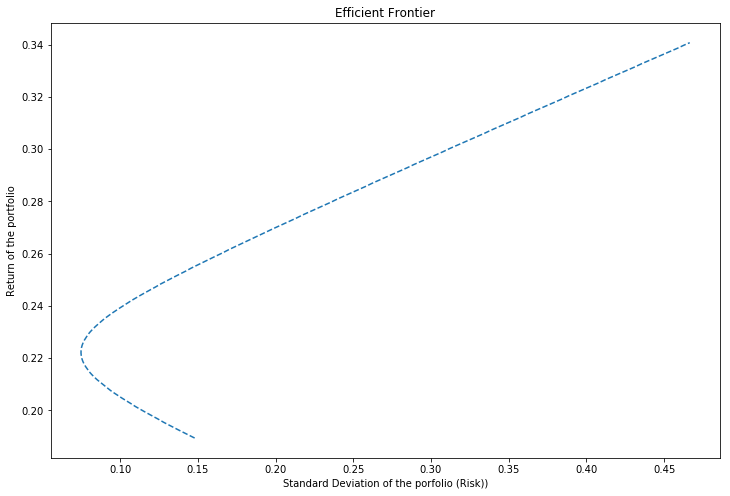

In [32]:
plot_efficient_frontier(frontier_data)